In [19]:
from simulate import *

import matplotlib.pyplot as plt

DATA_DIR = "/dtu/projects/02613_2025/data/modified_swiss_dwellings/"
N = 4
with open(join(DATA_DIR, 'building_ids.txt'), 'r') as f:
    building_ids = f.read().splitlines()
building_ids = building_ids[:N]

# Load floor plans
all_u0 = np.empty((N, 514, 514))
all_interior_mask = np.empty((N, 512, 512), dtype='bool')
for i, bid in enumerate(building_ids):
    u0, interior_mask = load_data(DATA_DIR, bid)
    all_u0[i] = u0
    all_interior_mask[i] = interior_mask

# Run jacobi iterations for each floor plan
MAX_ITER = 20_000
ABS_TOL = 1e-4

In [20]:
all_u = np.empty_like(all_u0)
for i, (u0, interior_mask) in enumerate(zip(all_u0, all_interior_mask)):
    u = jacobi(u0, interior_mask, MAX_ITER, ABS_TOL)
    all_u[i] = u

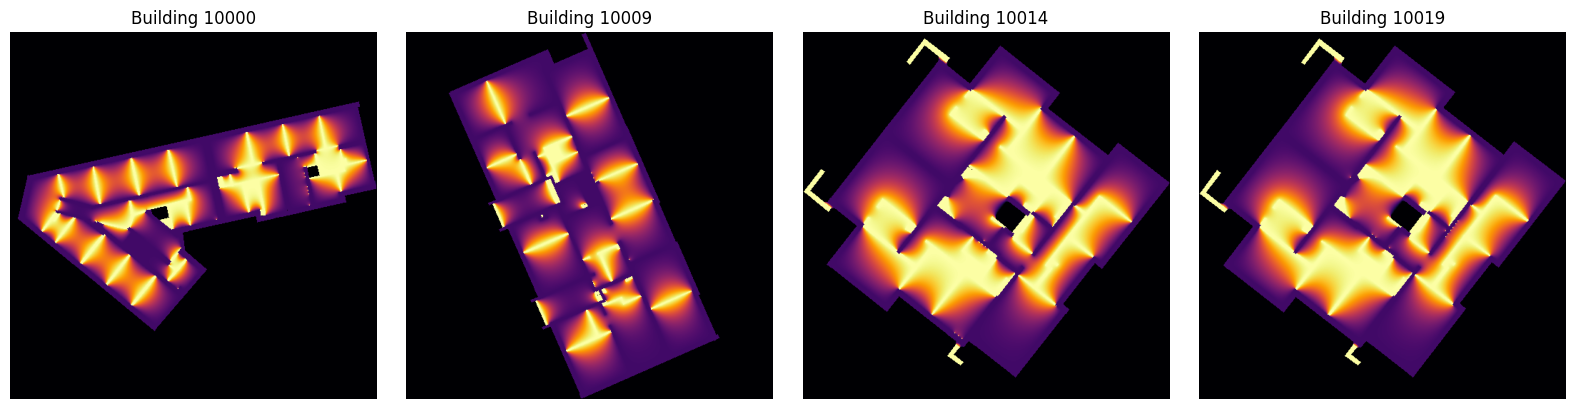

In [21]:
# Visualize the 4 buildings side by side
fig, axes = plt.subplots(1, N, figsize=(4 * N, 4))
for i in range(N):
    ax = axes[i]
    im = ax.imshow(all_u[i], cmap='inferno')
    ax.set_title(f"Building {building_ids[i]}")
    ax.axis('off')
plt.tight_layout()
plt.show()